In [ ]:
import numpy as np
import pandas as pd
original_matrix = pd.read_csv("./result/aou_binary_260217/prs_conditionalOR_matrix_260217_rootcode_qc.csv")
original_matrix = original_matrix.set_index("trait")
selected_trait = pd.read_csv("./result/aou_binary_260217/selected_trait.csv")
original_matrix = original_matrix.loc[original_matrix.index.isin(selected_trait["icd"])]

In [2]:
rank_matrix = pd.read_csv("./result/aou_binary_260217/prs_auc_matrix_260217_rootcode_rankmatrix.csv")
rank_matrix = rank_matrix.set_index("trait")
rank_matrix = rank_matrix.loc[rank_matrix.index.isin(selected_trait["icd"])]
metainfo = pd.read_csv("./disease_preprocess/pgs_metadata_260217.csv")
metainfo = metainfo.drop_duplicates(subset="PGS_ID", keep="first").set_index("PGS_ID")

In [68]:
def add_significance(ax, x1, x2, y, p):
    h = y * 0.05
    ax.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=1.5)
    
    if p < 0.001:
        text = "***"
    elif p < 0.01:
        text = "**"
    elif p < 0.05:
        text = "*"
    else:
        text = "ns"
    
    ax.text((x1+x2)/2, y+h, text, ha='center', va='bottom')

### Correlation: Number of Variants - Performance

In [82]:
matrix = original_matrix.copy()

num_variant_best = []
num_variant_median = []
num_variant_worst = []

for trait in rank_matrix.index:

    pgs_list = []
    num_list = []

    for m in rank_matrix.loc[trait]:

        if trait not in m.split("__")[0].split("+"):
            continue

        temp_id = m.split("__")[1]

        pgs_list.append(temp_id)

        num_var = metainfo.loc[temp_id]["num_variant"]
        num_list.append(num_var)

    if len(num_list) < 3:
        continue
    num_array = np.array(num_list)
    best = num_array[0]
    worst = num_array[-1]
    median = num_array[len(num_array) // 2]

    num_variant_best.append(best)
    num_variant_median.append(median)
    num_variant_worst.append(worst)

Global p: 0.01684525785191759


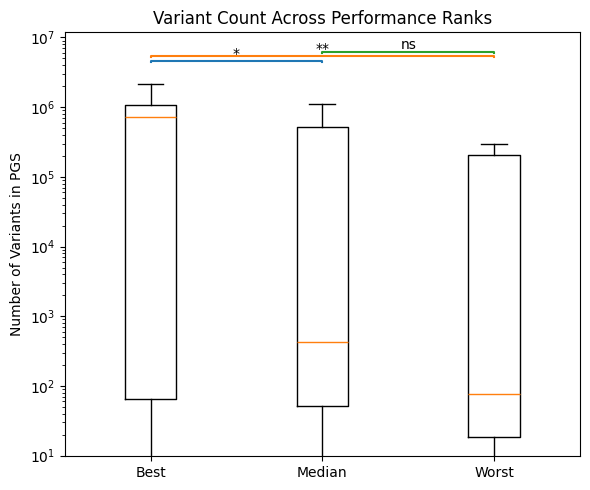

In [83]:
import matplotlib.pyplot as plt
from scipy.stats import kruskal, mannwhitneyu

# hypothesis testing
# overall test
stat, p_global = kruskal(
    num_variant_best,
    num_variant_median,
    num_variant_worst
)

print("Global p:", p_global)

# pairwise
p1 = mannwhitneyu(num_variant_best, num_variant_median).pvalue
p2 = mannwhitneyu(num_variant_best, num_variant_worst).pvalue
p3 = mannwhitneyu(num_variant_median, num_variant_worst).pvalue

fig, ax = plt.subplots(figsize=(6,5))

data = [num_variant_best, num_variant_median, num_variant_worst]

ax.boxplot(
    data,
    labels=["Best", "Median", "Worst"],
    showfliers=False
)

ax.set_yscale("log")
ax.set_ylabel("Number of Variants in PGS")
ax.set_title("Variant Count Across Performance Ranks")

# add pairwise significance
y_max = max([max(d) for d in data])

add_significance(ax, 1, 2, y_max*1.1, p1)
add_significance(ax, 1, 3, y_max*1.3, p2)
add_significance(ax, 2, 3, y_max*1.5, p3)

plt.tight_layout()
plt.show()

### Correlation: Number Training Sample - Performance

In [72]:
matrix = original_matrix.copy()

num_variant_best = []
num_variant_median = []
num_variant_worst = []

for trait in rank_matrix.index:

    pgs_list = []
    num_list = []

    for m in rank_matrix.loc[trait]:

        if trait not in m.split("__")[0].split("+"):
            continue

        temp_id = m.split("__")[1]

        pgs_list.append(temp_id)

        num_var = metainfo.loc[temp_id]["num_training_sample"]
        num_list.append(num_var)

    if len(num_list) < 3:
        continue
    num_array = np.array(num_list)
    best = num_array[0]
    worst = num_array[-1]
    median = num_array[len(num_array) // 2]

    num_variant_best.append(best)
    num_variant_median.append(median)
    num_variant_worst.append(worst)

Global p: 0.5135388406703869


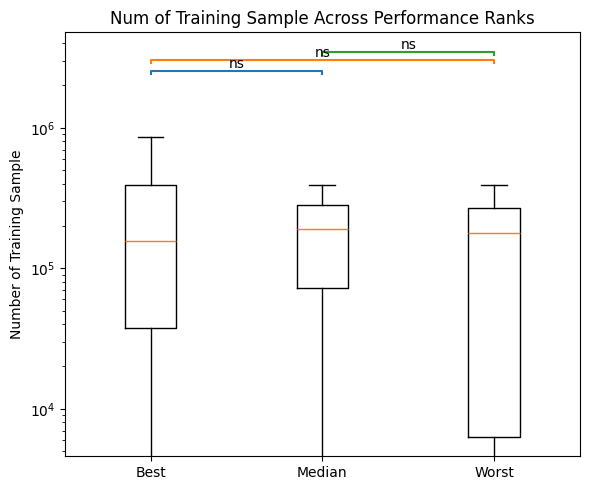

In [73]:
import matplotlib.pyplot as plt
from scipy.stats import kruskal, mannwhitneyu

num_variant_best = [x for x in num_variant_best if pd.notna(x)]
num_variant_median = [x for x in num_variant_median if pd.notna(x)]
num_variant_worst = [x for x in num_variant_worst if pd.notna(x)]

# hypothesis testing
# overall test
stat, p_global = kruskal(
    num_variant_best,
    num_variant_median,
    num_variant_worst
)

print("Global p:", p_global)

# pairwise
p1 = mannwhitneyu(num_variant_best, num_variant_median).pvalue
p2 = mannwhitneyu(num_variant_best, num_variant_worst).pvalue
p3 = mannwhitneyu(num_variant_median, num_variant_worst).pvalue

fig, ax = plt.subplots(figsize=(6,5))

data = [num_variant_best, num_variant_median, num_variant_worst]

ax.boxplot(
    data,
    labels=["Best", "Median", "Worst"],
    showfliers=False
)

ax.set_yscale("log")
ax.set_ylabel("Number of Training Sample")
ax.set_title("Num of Training Sample Across Performance Ranks")

# add pairwise significance
y_max = max([max(d) for d in data])

add_significance(ax, 1, 2, y_max*1.1, p1)
add_significance(ax, 1, 3, y_max*1.3, p2)
add_significance(ax, 2, 3, y_max*1.5, p3)

plt.tight_layout()
plt.show()

### Correlation: Date Release - Performance

In [84]:
matrix = original_matrix.copy()
today = pd.Timestamp.today()

days_best = []
days_median = []
days_worst = []

for trait in rank_matrix.index:

    days_list = []

    for m in rank_matrix.loc[trait]:

        if trait not in m.split("__")[0].split("+"):
            continue

        temp_id = m.split("__")[1]

        release_date = pd.to_datetime(metainfo.loc[temp_id]["date_release"])
        days_diff = (today - release_date).days

        days_list.append(days_diff)

    if len(days_list) < 3:
        continue

    days_array = np.array(days_list)

    days_best.append(days_array[0])
    days_median.append(days_array[len(days_array)//2])
    days_worst.append(days_array[-1])


Global p: 0.011247707514117897


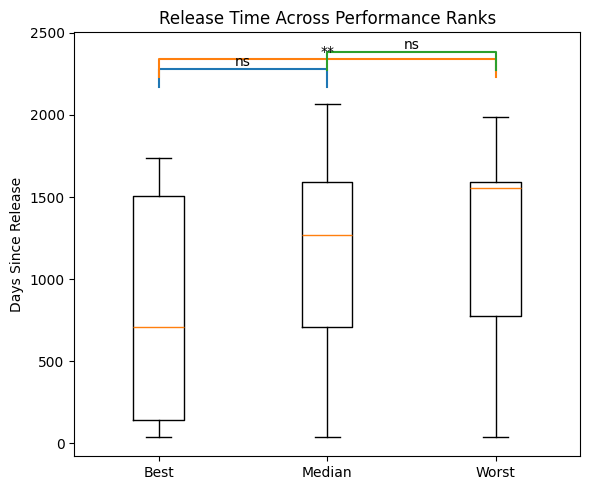

In [85]:
import matplotlib.pyplot as plt

num_variant_best = [x for x in days_best if pd.notna(x)]
num_variant_median = [x for x in days_median if pd.notna(x)]
num_variant_worst = [x for x in days_worst if pd.notna(x)]

# hypothesis testing
# overall test
stat, p_global = kruskal(
    num_variant_best,
    num_variant_median,
    num_variant_worst
)

print("Global p:", p_global)

# pairwise
p1 = mannwhitneyu(num_variant_best, num_variant_median).pvalue
p2 = mannwhitneyu(num_variant_best, num_variant_worst).pvalue
p3 = mannwhitneyu(num_variant_median, num_variant_worst).pvalue

fig, ax = plt.subplots(figsize=(6,5))

data = [num_variant_best, num_variant_median, num_variant_worst]

ax.boxplot(
    data,
    labels=["Best", "Median", "Worst"],
    showfliers=False
)

ax.set_ylabel("Days Since Release")
ax.set_title("Release Time Across Performance Ranks")

# add pairwise significance
y_max = max([max(d) for d in data])

add_significance(ax, 1, 2, y_max*1.05, p1)
add_significance(ax, 1, 3, y_max*1.08, p2)
add_significance(ax, 2, 3, y_max*1.10, p3)

plt.tight_layout()
plt.show()

### Correlation: Reported Performance - Performance

In [88]:
from scipy.stats import norm

def beta_to_auc(beta):
    return norm.cdf(beta / np.sqrt(2))

def or_to_auc(OR):
    beta = np.log(OR)
    return norm.cdf(beta / np.sqrt(2))

def partial_r_to_auc(r):
    d = 2*r / np.sqrt(1 - r**2)
    return norm.cdf(d / np.sqrt(2))

def perpare_report_performance(eval_estimate: list, eval_ancestry: list, eval_metrics: list) -> float:
    result = []
    for idx, estimate in enumerate(eval_estimate):
        if not eval_ancestry[idx] == 'European':
            continue
        metric = eval_metrics[idx]
        if not metric == "Odds Ratio":
            continue
        result.append(estimate)
    if len(result) > 0:
        return float(np.mean(result))
    else:
        return np.nan

In [89]:
import ast
matrix = original_matrix.copy()
today = pd.Timestamp.today()

days_best = []
days_median = []
days_worst = []

for trait in rank_matrix.index:

    days_list = []

    for m in rank_matrix.loc[trait]:

        if trait not in m.split("__")[0].split("+"):
            continue

        temp_id = m.split("__")[1]

        eval_estimate = ast.literal_eval(metainfo.loc[temp_id]["eval_estimate"])
        eval_ancestry = ast.literal_eval(metainfo.loc[temp_id]["eval_ancestry"])
        eval_metrics = ast.literal_eval(metainfo.loc[temp_id]["eval_metrics"])
        num_var = perpare_report_performance(eval_estimate, eval_ancestry, eval_metrics)

        days_list.append(num_var)

    if len(days_list) < 3:
        continue

    days_array = np.array(days_list)

    days_best.append(days_array[0])
    days_median.append(days_array[len(days_array)//2])
    days_worst.append(days_array[-1])

Global p: 0.1877343640070189


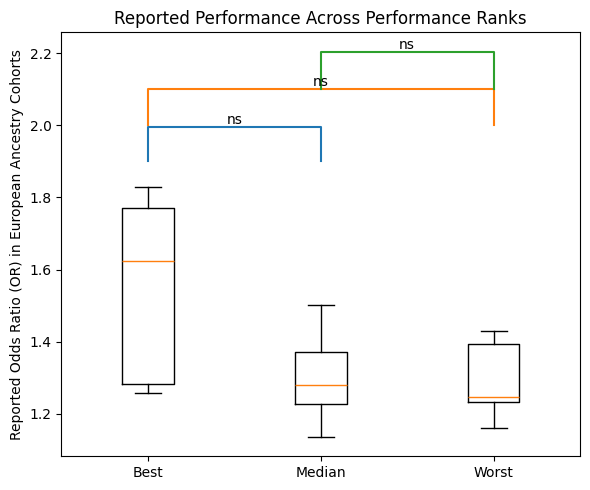

In [94]:
import matplotlib.pyplot as plt
from scipy.stats import kruskal, mannwhitneyu

num_variant_best = [x for x in days_best if pd.notna(x)]
num_variant_median = [x for x in days_median if pd.notna(x)]
num_variant_worst = [x for x in days_worst if pd.notna(x)]

# hypothesis testing
# overall test
stat, p_global = kruskal(
    num_variant_best,
    num_variant_median,
    num_variant_worst
)

print("Global p:", p_global)

# pairwise
p1 = mannwhitneyu(num_variant_best, num_variant_median).pvalue
p2 = mannwhitneyu(num_variant_best, num_variant_worst).pvalue
p3 = mannwhitneyu(num_variant_median, num_variant_worst).pvalue

fig, ax = plt.subplots(figsize=(6,5))

data = [num_variant_best, num_variant_median, num_variant_worst]

ax.boxplot(
    data,
    labels=["Best", "Median", "Worst"],
    showfliers=False
)

ax.set_ylabel("Reported Odds Ratio (OR) in European Ancestry Cohorts")
ax.set_title("Reported Performance Across Performance Ranks")

# add pairwise significance
y_max = max([max(d) for d in data])

add_significance(ax, 1, 2, 1.9, p1)
add_significance(ax, 1, 3, 2.0, p2)
add_significance(ax, 2, 3, 2.1, p3)

plt.tight_layout()
plt.show()

### Correlation: Training Cohorts - Performance

In [ ]:
matrix = original_matrix.copy()

days_best = []
days_median = []
days_worst = []

for trait in rank_matrix.index:

    days_list = []

    for m in rank_matrix.loc[trait]:

        if trait not in m.split("__")[0].split("+"):
            continue

        temp_id = m.split("__")[1]

        cohort = metainfo.loc[temp_id]["training_cohort"]

        days_list.append(cohort)

    if len(days_list) < 3:
        continue

    days_array = np.array(days_list)

    days_best.append(days_array[0])
    days_median.append(days_array[len(days_array)//2])
    days_worst.append(days_array[-1])

/var/folders/t3/fj07dpz50zn3x251k3gr9wxr0000gn/T/ipykernel_18688/3690366219.py:17: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap("tab20", len(all_cohorts))
/var/folders/t3/fj07dpz50zn3x251k3gr9wxr0000gn/T/ipykernel_18688/3690366219.py:53: UserWarning: Tight layout not applied. tight_layout cannot make axes width small enough to accommodate all axes decorations
  plt.tight_layout()


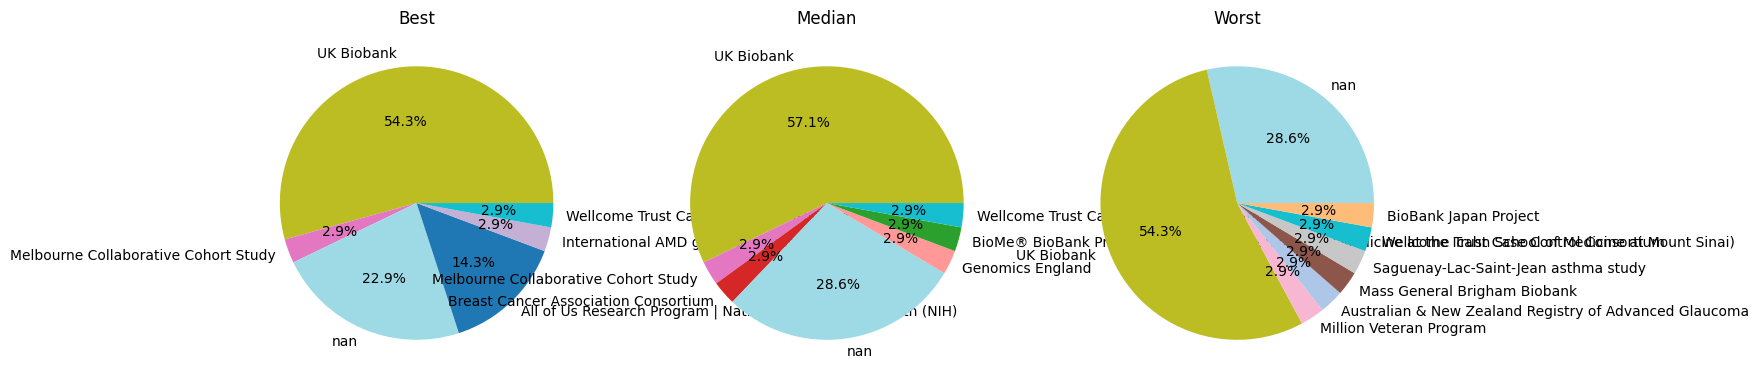

In [56]:
from collections import Counter
import matplotlib.pyplot as plt

best_counter = Counter(days_best)
median_counter = Counter(days_median)
worst_counter = Counter(days_worst)

all_cohorts = sorted(
    set(best_counter.keys())
    | set(median_counter.keys())
    | set(worst_counter.keys())
)

import matplotlib.cm as cm
import numpy as np

cmap = cm.get_cmap("tab20", len(all_cohorts))

color_map = {
    cohort: cmap(i)
    for i, cohort in enumerate(all_cohorts)
}

fig, axes = plt.subplots(1, 3, figsize=(15,5))

# Best
axes[0].pie(
    best_counter.values(),
    labels=best_counter.keys(),
    colors=[color_map[k] for k in best_counter.keys()],
    autopct='%1.1f%%'
)
axes[0].set_title("Best")

# Median
axes[1].pie(
    median_counter.values(),
    labels=median_counter.keys(),
    colors=[color_map[k] for k in median_counter.keys()],
    autopct='%1.1f%%'
)
axes[1].set_title("Median")

# Worst
axes[2].pie(
    worst_counter.values(),
    labels=worst_counter.keys(),
    colors=[color_map[k] for k in worst_counter.keys()],
    autopct='%1.1f%%'
)
axes[2].set_title("Worst")

plt.tight_layout()
plt.show()


### Correlation: Training Method - Performance

In [57]:
matrix = original_matrix.copy()

days_best = []
days_median = []
days_worst = []

for trait in rank_matrix.index:

    days_list = []

    for m in rank_matrix.loc[trait]:

        if trait not in m.split("__")[0].split("+"):
            continue

        temp_id = m.split("__")[1]

        cohort = metainfo.loc[temp_id]["training_method"]

        days_list.append(cohort)

    if len(days_list) < 3:
        continue

    days_array = np.array(days_list)

    days_best.append(days_array[0])
    days_median.append(days_array[len(days_array)//2])
    days_worst.append(days_array[-1])

/var/folders/t3/fj07dpz50zn3x251k3gr9wxr0000gn/T/ipykernel_18688/1429057178.py:17: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap("tab20", len(all_cohorts))
/var/folders/t3/fj07dpz50zn3x251k3gr9wxr0000gn/T/ipykernel_18688/1429057178.py:53: UserWarning: Tight layout not applied. tight_layout cannot make axes width small enough to accommodate all axes decorations
  plt.tight_layout()


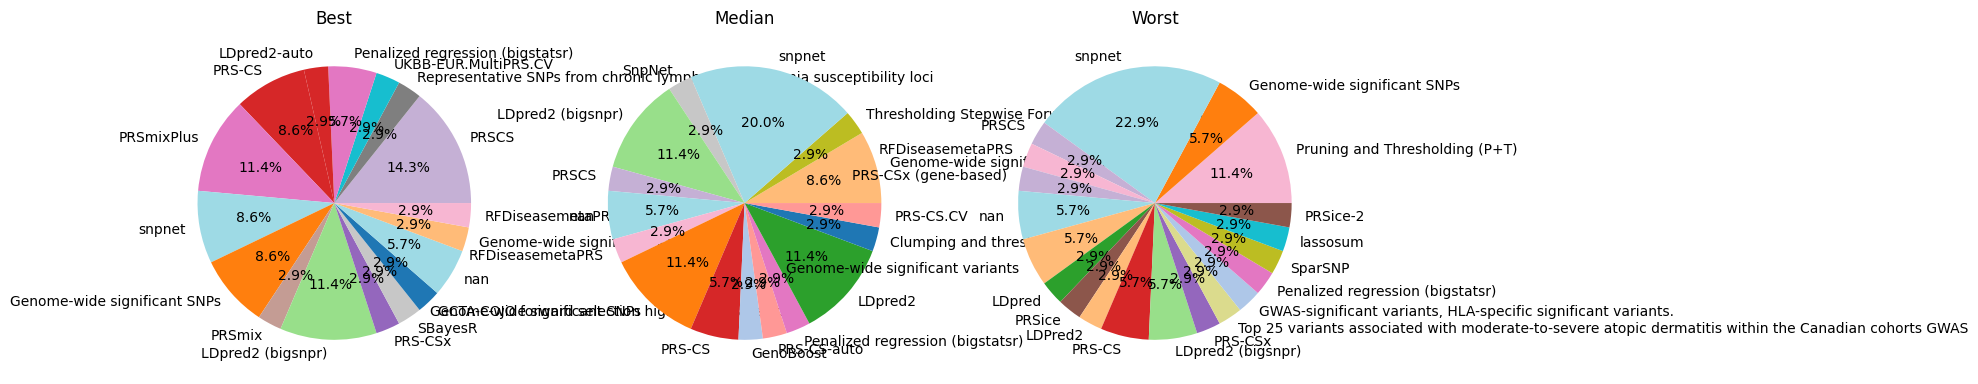

In [58]:
from collections import Counter
import matplotlib.pyplot as plt

best_counter = Counter(days_best)
median_counter = Counter(days_median)
worst_counter = Counter(days_worst)

all_cohorts = sorted(
    set(best_counter.keys())
    | set(median_counter.keys())
    | set(worst_counter.keys())
)

import matplotlib.cm as cm
import numpy as np

cmap = cm.get_cmap("tab20", len(all_cohorts))

color_map = {
    cohort: cmap(i)
    for i, cohort in enumerate(all_cohorts)
}

fig, axes = plt.subplots(1, 3, figsize=(15,5))

# Best
axes[0].pie(
    best_counter.values(),
    labels=best_counter.keys(),
    colors=[color_map[k] for k in best_counter.keys()],
    autopct='%1.1f%%'
)
axes[0].set_title("Best")

# Median
axes[1].pie(
    median_counter.values(),
    labels=median_counter.keys(),
    colors=[color_map[k] for k in median_counter.keys()],
    autopct='%1.1f%%'
)
axes[1].set_title("Median")

# Worst
axes[2].pie(
    worst_counter.values(),
    labels=worst_counter.keys(),
    colors=[color_map[k] for k in worst_counter.keys()],
    autopct='%1.1f%%'
)
axes[2].set_title("Worst")

plt.tight_layout()
plt.show()